In [1]:
  !apt-get update -qq
  !apt-get install -y tesseract-ocr \
      fonts-liberation fonts-freefont-ttf \
      fonts-urw-base35 fonts-dejavu
  !pip install -q pytesseract opencv-python \
      python-Levenshtein tqdm matplotlib Pillow

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-liberation is already the newest version (1:1.07.4-11).
tesseract-ocr is already the newest version (4.1.1-2.1build1).
Suggested packages:
  fonts-texgyre
The following NEW packages will be installed:
  fonts-dejavu fonts-dejavu-core fonts-dejavu-extra fonts-freefont-ttf
  fonts-urw-base35
0 upgraded, 5 newly installed, 0 to remove and 132 not upgraded.
Need to get 11.8 MB of archives.
After this operation, 28.8 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/

In [2]:

import cv2
import numpy as np
import pytesseract
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from Levenshtein import distance

warnings.filterwarnings("ignore")
random.seed(42)
np.random.seed(42)

In [3]:
WORD_LIST = list(set([
    # 3 chars
    "ace","arc","ash","axe","bay","bid","bit","box","cob","cod","cog",
    "cot","cub","cup","dam","den","dip","dot","dub","eel","ego","elm",
    "era","fig","fin","fog","fox","fur","gel","gem","gin","gnu","gum",
    "gut","hay","hex","hob","hop","hub","hug","hum","hut","imp","ink",
    "inn","ion","ivy","jar","jaw","jet","jog","jot","jug","keg","kin",
    "lab","lag","lap","lid","lip","log","lug","mop","mud","mug","nap",
    "nip","nod","nun","nut","oar","orb","ore","owl","pad","pan","paw",
    "peg","pod","pun","pup","rag","ram","rap","raw","ref","rep","rig",
    "rob","rod","rot","rub","rug","rum","rut","sag","sap","sax","sob",
    "sod","sow","spa","sub","sum","sup","tab","tag","tan","tar","tug",
    "urn","van","vat","vim","vow","wax","wig","woe","wok","yam","yew",
    "zap","zen","zip",
    # 4 chars
    "acid","arch","atom","barn","beam","beck","bile","bind","bolt","boon",
    "brow","buck","buoy","burp","bush","calm","cape","carp","cave","clan",
    "clam","clap","clip","clue","coal","coke","coil","cone","coop","cord",
    "core","cork","coup","curb","curl","damp","dare","darn","dart","dash",
    "daub","daze","deem","deft","dent","dice","dike","dime","dint","dire",
    "dock","dome","dote","dove","drip","drub","drum","dull","dusk","fare",
    "fawn","faze","feat","fend","fern","fete","feud","fief","fife","flit",
    "flop","flub","flux","foil","fond","fond","fore","fork","fume","furl",
    "gale","gape","gash","gawk","gaze","geld","gild","gird","glee","glop",
    "gory","goat","goon","gore","gown","gust","hack","hale","halt","hank",
    "harp","haze","helm","hemp","herd","hewn","hike","hilt","hint","hire",
    "hive","hone","hoop","howl","hulk","hull","hump","hymn","idle","itch",
    "jade","jibe","jilt","jink","jive","joust","keen","kelp","kiln","knit",
    "knob","knot","lace","lame","lard","lark","lash","laud","lava","laze",
    "lick","limp","loft","loom","lope","lore","lull","lump","lung","lure",
    "lurk","lute","mace","mane","mare","mast","maul","maze","meld","mend",
    "mire","mist","moan","mode","mole","moat","molt","mope","mort","muck",
    "mull","narc","nave","nigh","numb","ogle","okra","omen","omit","opus",
    "orca","orgy","ouzo","pale","pall","pang","pave","peal","peck","peek",
    "peon","pike","plop","plum","ploy","pore","pout","pram","prig","prow",
    "pulp","punt","pyre","quay","rack","raft","rage","rapt","raze","ream",
    "reek","rein","rend","rife","rime","rind","rite","roan","robe","rove",
    "rung","rush","rust","sage","sake","sear","serf","sewn","sham","shin",
    "shorn","shun","silt","skew","slab","slag","slam","slew","slop","slug",
    "slur","smug","snag","snip","snob","snub","soak","soar","sore","spat",
    "spew","spin","spit","spud","spur","stab","stem","stew","stub","stud",
    "stun","suds","sulk","sump","swab","swam","swap","swat","tack","tame",
    "taut","teem","temp","tend","tern","tick","tiff","tilt","tome","tong",
    "toot","tort","toss","tout","trod","trot","tuff","tuft","tuft","tump",
    "turf","tusk","twit","undo","vain","vale","vane","vary","veer","veil",
    "vend","vent","verb","vest","veto","vex","vial","vile","vine","vise",
    "wade","wage","wail","wane","warp","wary","weld","wend","whet","whim",
    "whip","wick","wilt","wimp","wince","wink","wiry","wisp","writ","wry",
    "yore","zeal","zest","zinc","zone",
    # 5 chars
    "abbot","abhor","abide","abyss","adept","adorn","adrift","agile",
    "agony","algae","alibi","aloft","alter","amble","amend","amiss",
    "ample","annex","antic","anvil","aorta","ardor","argue","arid",
    "attic","augur","avian","avid","axial","azure","baste","batch",
    "bawdy","belfry","berth","beset","bevel","bight","bison","bland",
    "blare","bleat","bleed","blight","bliss","bloat","bloke","blunt",
    "blurt","blush","bogus","braid","brand","brash","brawn","brawl",
    "braze","brief","brine","brink","brood","broth","brunt","bugle",
    "bulge","bully","bunny","buret","burly","buxom","cabal","cadge",
    "cairn","camel","cameo","cargo","carve","cedar","chafe","chalk",
    "champ","chant","chaos","chimp","chive","choke","chore","cinch",
    "civic","cleft","clerk","clink","cloak","clown","clump","cobra",
    "comet","coral","couch","cough","covet","cramp","crave","creak",
    "crest","croak","crone","crook","croon","crumb","crude","crypt",
    "cuing","daunt","delve","depot","derby","devil","digit","dirge",
    "ditty","dodge","dowel","dowry","drake","drawl","drone","drove",
    "elope","embed","erupt","evade","evict","exert","exude","faint",
    "faker","farce","fatal","fauna","ferret","fetid","finch","fjord",
    "flail","flank","flare","fleek","flesh","flinch","flint","flock",
    "flung","flunk","flute","foray","forge","frail","frank","fraud",
    "frond","froth","frugal","fugue","fully","fungi","gaudy","gawky",
    "geyser","ghoul","girth","gizmo","gleam","glean","glint","gloat",
    "glyph","gnash","gnome","golly","gorge","gouge","grace","graft",
    "grail","greed","grime","gripe","groan","groin","grout","growl",
    "gruel","grunt","guile","gusto","gyrate","haven","havoc","hazel",
    "hefty","heist","helix","hertz","hippo","horde","hound","howdy",
    "husky","idiom","igloo","inane","inept","inert","ingot","inlay",
    "inure","irony","jaunt","jelly","jiffy","joust","juror","knave",
    "kneel","kudos","lapel","larva","lavish","leach","leafy","leaky",
    "ledge","leery","lemma","liege","liner","lithe","livid","llama",
    "lodge","loopy","lurch","lusty","lyric","malign","manor","marsh",
    "melee","mirth","moose","mourn","muddy","murky","musty","nadir",
    "naive","noisy","notch","nudge","okapi","onslaught","optic","orate",
    "oxide","ozone","paddy","parch","patsy","penal","perch","pesky",
    "petty","pique","pithy","pivot","plead","pleat","pluck","plume",
    "plunk","poach","poise","poppy","posse","prank","preen","probe",
    "prowl","proxy","psalm","pulpy","purge","pygmy","quake","quell",
    "quirk","quota","raspy","raven","reedy","repel","rivet","roost",
    "ruddy","rupee","scald","scalp","scant","scoff","scone","scope",
    "scour","scowl","scram","scrub","scuff","seedy","seize","servo",
    "shard","sheaf","sheen","shrub","siege","simmer","sinew","skirt",
    "skimp","skulk","slain","slant","slash","sleek","sleet","slept",
    "slime","sling","slunk","snarl","sneak","sneer","snort","snout",
    "snuff","soggy","sovereign","spare","spawn","speck","spelt","spiel",
    "spire","splat","spoof","spore","spout","spree","spunk","stale",
    "stalk","stall","stave","sleek","stomp","stork","strap","straw",
    "strut","stump","stunt","sulky","surly","swath","swirl","swoop",
    "tacit","taint","talon","tarry","taunt","tawny","tepid","thief",
    "thong","thorn","thump","timid","tipsy","tithe","tonic","topaz",
    "totem","toxin","tramp","tweak","tweed","ulcer","undue","usher",
    "uvula","vague","valor","valve","vapor","vault","venom","verge",
    "vigil","viper","vogue","vouch","wafer","waltz","weedy","welch",
    "whirl","wield","wrath","wreak","wrung","yacht","yearn","zebra",
    # 6-7 chars
    "ablaze","absent","accent","accord","accrue","adhere","adjoin","advent",
    "affirm","afflux","afford","affront","anchor","angler","anneal","annuity",
    "anoint","antler","aplomb","armour","aspire","assail","assign","attest",
    "attire","august","baboon","badger","baffle","ballot","banter","barren",
    "beaker","beckon","bedlam","bemoan","berate","beside","bicker","blanket",
    "blazon","blotch","bobcat","boggle","border","bother","botnet","bounce",
    "bounty","brawler","breeze","brimstone","broker","bronze","bruise","budget",
    "bustle","butler","canopy","cavern","censor","charade","chrome","cinder",
    "cipher","clamor","clench","clergy","clobber","coerce","column","combat",
    "comet","compel","comply","concur","condor","confer","convey","copper",
    "cornet","corset","cosmos","covert","crater","cripple","crocus","cruelty",
    "cudgel","defect","deflect","deform","defunct","deluge","demote","denial",
    "deport","devour","differ","disarm","disown","disrupt","divert","domain",
    "domino","doused","downturn","drought","duress","earnest","earthy",
    "emblem","enlist","evasion","exempt","exhale","fabric","famine","fathom",
    "feline","fervor","festive","fetish","fetter","fierce","filthy","fissure",
    "fixate","fixture","flannel","flatten","fleece","flicker","flinch","florid",
    "flushed","flutter","forbid","fossil","foster","frenzy","fright","frozen",
    "fulcrum","fumble","gallop","gambit","garble","garnet","gentle","gibbet",
    "gibbon","girder","glacial","gladden","glitter","glottal","govern","gravel",
    "groggy","grovel","grudge","grumble","gurgle","hamper","harden","hateful",
    "haywire","hermit","hinder","hoarse","hobble","holster","hornet","humble",
    "hunger","hunter","hybrid","ignite","illicit","impede","import","impose",
    "impugn","intent","invoke","irrupt","jabber","jangle","jester","jilted",
    "jobless","jostle","jounce","jumble","jungle","junior","kernel","kidnap",
    "kiosk","lament","lantern","larceny","lavish","lessen","lethal","levity",
    "linker","locket","lofty","loosen","lucid","lumber","lunacy","mantle",
    "marble","marshy","mayhem","meddle","melting","menace","mentor","mingle",
    "miscue","mishap","morose","mortar","mottled","muster","myriad","narrow",
    "nimble","nomad","noxious","nurture","ocelot","offset","oppose","ordeal",
    "orphan","outrun","outwit","pallor","pander","pardon","parody","patent",
    "pepper","peril","perjure","permit","petrel","pilfer","plunge","potion",
    "potent","potter","pounce","prefer","purport","quicken","radiant","rampage",
    "rancor","random","ravage","recant","recede","reckon","recoil","recoup",
    "redeem","refute","relent","renown","repent","rescue","resign","resist",
    "ridden","robust","rugged","rustle","sabotage","saddle","safeguard","salvage",
    "sampler","savage","scarce","sector","sensor","serene","settle","shimmer",
    "shriek","simile","sinker","smudge","snaffle","snivel","somber","sorrow",
    "sponge","sprout","squall","squash","stable","stalker","staple","startle",
    "static","stifle","stipend","stormy","stout","strangle","strident","strive",
    "subdue","subtle","succumb","suitor","sultan","summon","sunder","supple",
    "surpass","sustain","swindle","symbol","tandem","tangle","target","tartan",
    "tatter","teller","temple","tenure","tether","tirade","tither","toiler",
    "torment","torrent","tourney","trespass","trigger","triumph","trudge",
    "turbine","twinge","typhoon","unravel","upshot","vanish","vanquish","varnish",
    "vaulted","vendor","verdict","vermin","vestige","vibrant","village","villain",
    "vintage","virtuous","warden","warden","warlock","waylaid","wicket","wither",
    "zealot","zephyr",
]))

# Ensure consistent seed-reproducible shuffle
WORD_LIST = sorted(WORD_LIST)
random.shuffle(WORD_LIST)
print(f"Vocabulary size: {len(WORD_LIST)} words")


Vocabulary size: 1251 words


In [4]:
FONT_DIRS = [
    "/usr/share/fonts/truetype/liberation",
    "/usr/share/fonts/truetype/freefont",
    "/usr/share/fonts/truetype/dejavu",
    "/usr/share/fonts/truetype/ubuntu",
    "/usr/share/fonts/truetype/urw-base35",
    "/usr/share/fonts/truetype",
    "/usr/share/fonts",
]

EXCLUDE_KEYWORDS = [
    "bold","italic","oblique","narrow","condensed","light","thin",
    "black","heavy","medium","semi","ext","cjk","emoji","math",
    "symbol","dingbat","webdings","wingding",
]

def find_fonts() -> list:
    found = []
    for d in FONT_DIRS:
        if not os.path.isdir(d):
            continue
        for f in Path(d).rglob("*.ttf"):
            name_lower = f.name.lower()
            if any(kw in name_lower for kw in EXCLUDE_KEYWORDS):
                continue
            found.append(str(f))
    # Deduplicate by filename stem
    seen, unique = set(), []
    for f in found:
        stem = Path(f).stem.lower()
        if stem not in seen:
            seen.add(stem)
            unique.append(f)
    return unique

AVAILABLE_FONTS = find_fonts()

if not AVAILABLE_FONTS:
    raise RuntimeError(
        "No fonts found. Run:\n"
        "  apt-get install -y fonts-liberation fonts-freefont-ttf fonts-dejavu"
    )

print(f"Fonts available  : {len(AVAILABLE_FONTS)}")
for f in AVAILABLE_FONTS[:8]:
    print(f"  {Path(f).name}")
if len(AVAILABLE_FONTS) > 8:
    print(f"  ... and {len(AVAILABLE_FONTS)-8} more")



Fonts available  : 10
  LiberationMono-Regular.ttf
  LiberationSerif-Regular.ttf
  LiberationSans-Regular.ttf
  FreeSerif.ttf
  FreeMono.ttf
  FreeSans.ttf
  DejaVuSans.ttf
  DejaVuSansMono.ttf
  ... and 2 more


In [5]:
def render_word_image(word: str,
                      font_path: str,
                      font_size: int,
                      bg_mean: int = 240,
                      text_mean: int = 18) -> np.ndarray:
    try:
        font = ImageFont.truetype(font_path, font_size)
    except Exception:
        font = ImageFont.load_default()

    dummy = Image.new("L", (1, 1))
    bbox  = ImageDraw.Draw(dummy).textbbox((0, 0), word, font=font)
    text_w = max(bbox[2] - bbox[0], 1)
    text_h = max(bbox[3] - bbox[1], 1)

    pad = 10
    W, H = text_w + 2 * pad, text_h + 2 * pad

    bg_noise = np.random.normal(bg_mean, 4, (H, W)).clip(210, 255).astype(np.uint8)
    img      = Image.fromarray(bg_noise, mode="L")
    draw     = ImageDraw.Draw(img)
    text_col = int(np.clip(np.random.normal(text_mean, 5), 0, 40))
    draw.text((pad - bbox[0], pad - bbox[1]), word, font=font, fill=text_col)
    return np.array(img)


def build_dataset(n_samples: int) -> list:
    words = (WORD_LIST * ((n_samples // len(WORD_LIST)) + 1))[:n_samples]
    random.shuffle(words)
    dataset = []
    for word in tqdm(words, desc="Generating images"):
        img = render_word_image(
            word,
            random.choice(AVAILABLE_FONTS),
            random.randint(28, 44)
        )
        dataset.append((word, img))
    return dataset

In [6]:
SEVERITY_PARAMS = {
    "blur": {
        "mild":   {"ksize": (5,  5)},
        "medium": {"ksize": (9,  9)},
        "severe": {"ksize": (15, 15)},
    },
    "skew": {
        "mild":   {"angle": 6},
        "medium": {"angle": 16},
        "severe": {"angle": 27},
    },
    "contrast": {
        # alpha compresses dynamic range; beta shifts brightness down
        # mild:   still recognisable, slight washout
        # medium: noticeable graying, harder to read
        # severe: very flat histogram, most detail lost
        "mild":   {"alpha": 0.70, "beta": 18},
        "medium": {"alpha": 0.48, "beta": 12},
        "severe": {"alpha": 0.28, "beta":  6},
    },
}

DISTORTION_TYPES = ["blur", "skew", "contrast"]
SEVERITIES       = ["mild", "medium", "severe"]


def apply_distortion(image: np.ndarray,
                     dist_type: str,
                     severity: str) -> np.ndarray:
    p = SEVERITY_PARAMS[dist_type][severity]

    if dist_type == "blur":
        return cv2.GaussianBlur(image, p["ksize"], 0)

    elif dist_type == "skew":
        rows, cols = image.shape[:2]
        # Deterministic angle from image dimensions for reproducibility
        angle = p["angle"] * np.sign(np.sin(rows * cols))
        if angle == 0:
            angle = p["angle"]
        M = cv2.getRotationMatrix2D((cols / 2, rows / 2), angle, 1.0)
        return cv2.warpAffine(image, M, (cols, rows),
                              borderMode=cv2.BORDER_REPLICATE)

    elif dist_type == "contrast":
        return cv2.convertScaleAbs(image, alpha=p["alpha"], beta=p["beta"])

    raise ValueError(f"Unknown distortion: {dist_type}")


def apply_combined(image: np.ndarray, severity: str) -> np.ndarray:
    """Apply blur + skew + contrast at given severity (stress test)."""
    for dt in DISTORTION_TYPES:
        image = apply_distortion(image, dt, severity)
    return image

In [7]:
def laplacian_variance(image: np.ndarray) -> float:
    """
    Sharpness proxy. Calibrated for 96px-upscaled synthetic images:
      clean              ≈ 800-2000
      mild blur (5×5)   ≈ 300-500
      medium blur (9×9) ≈ 80-250
      severe blur(15×15)≈ 15-70
    Threshold 450: fires on mild/medium/severe blur, not on clean.
    """
    return float(cv2.Laplacian(image, cv2.CV_64F).var())


def contrast_std(image: np.ndarray) -> float:
    """
    Pixel std dev as contrast proxy.
      clean synthetic    ≈ 55-75
      mild contrast      ≈ 42-52
      medium contrast    ≈ 28-40
      severe contrast    ≈ 12-25
    Threshold 38: fires on medium/severe, barely touches mild.
    """
    return float(image.std())


def skew_angle(image: np.ndarray) -> float:
    """
    Estimate skew on thresholded binary to exclude background pixels.
    Raw grayscale contains background gradients that bias the bounding
    box angle estimate.
    """
    _, binary = cv2.threshold(image, 0, 255,
                              cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = np.column_stack(np.where(binary > 0))
    if len(coords) < 10:
        return 0.0
    angle = cv2.minAreaRect(coords)[-1]
    return -(90 + angle) if angle < -45 else -angle

In [8]:
def to_gray(image: np.ndarray) -> np.ndarray:
    if len(image.shape) == 3:
        return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return image.copy()


def upscale(image: np.ndarray, target_height: int = 96) -> np.ndarray:
    """
    INTER_CUBIC: smoother than LINEAR for upscaling, no ringing
    unlike LANCZOS for the small scale factors here (1.9-3.2×).
    96px: empirical sweet spot for Tesseract LSTM on word images.
    """
    h, w = image.shape[:2]
    if h >= target_height:
        return image
    scale = target_height / h
    return cv2.resize(image, (max(int(w * scale), 1), target_height),
                      interpolation=cv2.INTER_CUBIC)


def fix_inversion(image: np.ndarray) -> np.ndarray:
    """
    Ensure dark text on light background (Tesseract requirement).
    Threshold 85 (not 127): contrast-enhanced images have expanded
    histograms where mean correctly reflects background. Using 127
    would misclassify medium-gray images.

    ORDERING REQUIREMENT: must be called AFTER enhance_contrast_safe().
    Severe contrast distortion (alpha=0.28) compresses mean to ~85-95,
    which would trip this check on a light-background image if called
    on the raw distorted image. After linear stretch, mean correctly
    separates genuine dark-background from compressed-histogram images.
    """
    return cv2.bitwise_not(image) if image.mean() < 85 else image


def enhance_contrast_safe(image: np.ndarray) -> np.ndarray:
    """
    Contrast enhancement with noise-safety built in.

    Linear percentile stretch (2nd-98th percentile):
      - Does not amplify local variation (unlike CLAHE)
      - Safe regardless of noise level
      - Correctly expands a compressed histogram to full 0-255 range
      - On a severely contrast-reduced image (alpha=0.28), the pixel
        range might be 60-120; stretch maps this to 0-255

    CLAHE is intentionally avoided here because IIIT5K experiments
    confirmed it amplifies background texture on non-uniform images,
    confusing Tesseract's binarization step.
    """
    lo  = float(np.percentile(image, 2))
    hi  = float(np.percentile(image, 98))
    if hi - lo < 20:
        # Histogram is so flat that stretch would just amplify noise
        return image
    stretched = (image.astype(np.float32) - lo) / (hi - lo) * 255.0
    return np.clip(stretched, 0, 255).astype(np.uint8)


def unsharp_mask(image: np.ndarray,
                 sigma: float = 2.0,
                 strength: float = 2.5) -> np.ndarray:
    """
    Unsharp masking for blur recovery.
    strength=2.5 gives meaningful recovery of 9×9 Gaussian blur.
    Two passes applied for severe blur (lv < 80).

    MUST be called after any denoising — unsharp masking amplifies
    ALL high-frequency content, including noise.
    """
    blurred   = cv2.GaussianBlur(image, (0, 0), sigma)
    sharpened = cv2.addWeighted(image, 1.0 + strength, blurred, -strength, 0)
    return np.clip(sharpened, 0, 255).astype(np.uint8)


def morphological_close(image: np.ndarray) -> np.ndarray:
    """
    Horizontal closing fills small gaps in character strokes before
    binarization sees them.
    3×1 kernel: targets horizontal gaps only; wider kernel would
    merge vertically adjacent characters in tight text.
    Applied after blur recovery, before binarization.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 1))
    return cv2.morphologyEx(image, cv2.MORPH_CLOSE, kernel)


def smart_binarize(image: np.ndarray) -> np.ndarray:
    """
    Conditional binarization based on current contrast level.

    std > 65: return grayscale as-is.
      Tesseract LSTM uses anti-aliasing gradient information for
      sub-pixel character geometry. Hard binarization on a clean
      high-contrast image destroys this, degrading accuracy.

    30 < std ≤ 65: Otsu global threshold.
      Histogram has two clear modes (text vs background); Otsu
      finds the optimal separating threshold automatically.

    std ≤ 30: Adaptive threshold.
      Very flat histogram means global Otsu will mis-threshold
      large regions. Adaptive equalises locally.
    """
    std = contrast_std(image)
    if std > 65:
        return image
    if std > 30:
        _, result = cv2.threshold(image, 0, 255,
                                  cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        return result
    return cv2.adaptiveThreshold(image, 255,
                                 cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                 cv2.THRESH_BINARY, 15, 8)


def correct_skew(image: np.ndarray) -> np.ndarray:
    """
    Threshold 2.5° (raised from 1.5° in v3).
    At < 2.5°, minAreaRect on sparse foreground coords produces false
    positives from character shape variation: glyphs A, V, W, X have
    strong diagonal edges that bias the bounding box angle estimate.
    Raising the threshold prevents rotating genuinely straight text.
    """
    angle = skew_angle(image)
    if abs(angle) < 2.5:
        return image
    h, w = image.shape[:2]
    M    = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
    return cv2.warpAffine(image, M, (w, h),
                          flags=cv2.INTER_CUBIC,
                          borderMode=cv2.BORDER_REPLICATE)


def add_padding(image: np.ndarray, pad: int = 12) -> np.ndarray:
    """Tesseract silently drops characters touching the image boundary."""
    return cv2.copyMakeBorder(image, pad, pad, pad, pad,
                              cv2.BORDER_CONSTANT, value=255)


In [9]:
def adaptive_preprocess(image: np.ndarray) -> np.ndarray:
    gray = to_gray(image)
    gray = upscale(gray, target_height=96)

    # Measure quality on the upscaled raw image
    cs = contrast_std(gray)
    lv = laplacian_variance(gray)

    # ── Step 1: Contrast enhancement (before inversion check) ──
    # Threshold 38: clean std ≈ 55-75, mild ≈ 42-52, medium ≈ 28-40
    # Fires on medium/severe contrast distortion, not on clean images.
    if cs < 38:
        gray = enhance_contrast_safe(gray)

    # ── Step 2: Inversion check (after contrast enhancement) ───
    # Now the histogram is stretched — mean correctly identifies
    # genuine dark-background images.
    gray = fix_inversion(gray)

    # ── Step 3: Blur recovery ───────────────────────────────────
    # Re-measure after contrast enhancement (stretch changes lv).
    # Threshold 450: clean lv ≈ 800+, mild blur ≈ 300-500
    # Two passes for severe (lv < 80), one for mild/medium.
    lv_post = laplacian_variance(gray)
    if lv_post < 450:
        passes = 2 if lv_post < 80 else 1
        for _ in range(passes):
            gray = unsharp_mask(gray, sigma=2.0, strength=2.5)

    # ── Step 4: Morphological close ────────────────────────────
    gray = morphological_close(gray)

    # ── Step 5: Binarize ───────────────────────────────────────
    gray = smart_binarize(gray)

    # ── Step 6: Deskew ─────────────────────────────────────────
    gray = correct_skew(gray)

    # ── Step 7: Padding ────────────────────────────────────────
    gray = add_padding(gray, pad=12)
    return gray


def baseline_preprocess(image: np.ndarray) -> np.ndarray:
    """
    Minimal pipeline shared by both evaluation arms.
    Upscale + inversion + padding only.
    Delta between arms = value of the adaptive steps exclusively.
    Inversion applied here too so baseline isn't penalised
    for mis-orientation — we measure preprocessing benefit, not
    orientation handling.
    """
    gray = to_gray(image)
    gray = upscale(gray, target_height=96)
    gray = fix_inversion(gray)
    gray = add_padding(gray, pad=12)
    return gray


In [10]:
TESS_CONFIG = (
    "--psm 8 --oem 3 "
    "-c tessedit_char_whitelist="
    "ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz0123456789"
)

def run_ocr(image: np.ndarray) -> str:
    return pytesseract.image_to_string(image, config=TESS_CONFIG).strip()


In [11]:
def cer(pred: str, gt: str) -> float:
    """Character Error Rate: Levenshtein distance normalised by GT length."""
    return distance(pred.lower(), gt.lower()) / max(len(gt), 1)

def exact_match(pred: str, gt: str) -> float:
    """Exact word match — correct metric for single-word datasets."""
    return 1.0 if pred.lower() == gt.lower() else 0.0

In [12]:
def sanity_check(dataset: list, n: int = 40) -> float:
    print("\nSanity check: clean image accuracy...")
    sample  = random.sample(dataset, min(n, len(dataset)))
    correct = sum(
        exact_match(run_ocr(baseline_preprocess(img)), word)
        for word, img in tqdm(sample, desc="  Clean baseline")
    )
    acc = correct / len(sample)
    print(f"  Clean word accuracy: {acc:.3f}  ({int(correct)}/{len(sample)})")
    if acc < 0.80:
        print("  WARNING: Clean accuracy < 0.80.")
        print("  Check font installation and --psm 8 config.")
    else:
        print("  ✓ Acceptable — proceeding.")
    return acc

In [13]:
N_GENERATE  = 400
SAMPLE_SIZE = 200

print(f"\nGenerating {N_GENERATE} synthetic word images...")
dataset = build_dataset(N_GENERATE)

clean_acc = sanity_check(dataset)

eval_set = random.sample(dataset, min(SAMPLE_SIZE, len(dataset)))

results  = defaultdict(lambda: defaultdict(
    lambda: {"base_cer": [], "pre_cer": [], "base_acc": [], "pre_acc": []}))
combined = defaultdict(
    lambda: {"base_cer": [], "pre_cer": [], "base_acc": [], "pre_acc": []})

total = len(DISTORTION_TYPES) * len(SEVERITIES) + len(SEVERITIES)
print(f"\nEvaluating {SAMPLE_SIZE} images × {total} conditions × 2 pipelines...\n")

for word, img in tqdm(eval_set, desc="Evaluating"):

    # Per-distortion, per-severity — same distorted image for both pipelines
    for dt in DISTORTION_TYPES:
        for sv in SEVERITIES:
            distorted = apply_distortion(img.copy(), dt, sv)
            pred_base = run_ocr(baseline_preprocess(distorted))
            pred_pre  = run_ocr(adaptive_preprocess(distorted))
            r = results[dt][sv]
            r["base_cer"].append(cer(pred_base, word))
            r["pre_cer"].append(cer(pred_pre,   word))
            r["base_acc"].append(exact_match(pred_base, word))
            r["pre_acc"].append(exact_match(pred_pre,   word))

    # Combined stress test (blur + skew + contrast)
    for sv in SEVERITIES:
        dist_c    = apply_combined(img.copy(), sv)
        pred_base = run_ocr(baseline_preprocess(dist_c))
        pred_pre  = run_ocr(adaptive_preprocess(dist_c))
        c = combined[sv]
        c["base_cer"].append(cer(pred_base, word))
        c["pre_cer"].append(cer(pred_pre,   word))
        c["base_acc"].append(exact_match(pred_base, word))
        c["pre_acc"].append(exact_match(pred_pre,   word))



Generating 400 synthetic word images...


Generating images: 100%|██████████| 400/400 [00:00<00:00, 762.30it/s]



Sanity check: clean image accuracy...


  Clean baseline: 100%|██████████| 40/40 [00:07<00:00,  5.53it/s]


  Clean word accuracy: 0.950  (38/40)
  ✓ Acceptable — proceeding.

Evaluating 200 images × 12 conditions × 2 pipelines...



Evaluating: 100%|██████████| 200/200 [12:47<00:00,  3.84s/it]


In [14]:
SEP  = "─" * 84
SEP2 = "═" * 84

def marker(val, metric="cer"):
    if metric == "cer":
        return "▼" if val < -0.015 else ("▲" if val > 0.015 else "≈")
    return "▲" if val > 0.015 else ("▼" if val < -0.015 else "≈")

def fmt_row(label, bc, pc, ba, pa):
    dc, da = pc - bc, pa - ba
    return (
        f"  {label:<12}  "
        f"CER {bc:.4f} → {pc:.4f}  {dc:+.4f}{marker(dc,'cer')}  │  "
        f"Acc {ba:.4f} → {pa:.4f}  {da:+.4f}{marker(da,'acc')}"
    )

all_dc, all_da = [], []

print(f"\n{SEP2}")
print(f"  STRATIFIED RESULTS v6   (▼CER = better | ▲Acc = better)")
print(f"  Clean image word accuracy: {clean_acc:.3f}")
print(SEP2)

for dt in DISTORTION_TYPES:
    print(f"\n  ▌ {dt.upper()}")
    print(f"  {SEP}")
    for sv in SEVERITIES:
        r  = results[dt][sv]
        bc = np.mean(r["base_cer"]);  pc = np.mean(r["pre_cer"])
        ba = np.mean(r["base_acc"]); pa = np.mean(r["pre_acc"])
        print(fmt_row(sv, bc, pc, ba, pa))
        all_dc.append(pc - bc);  all_da.append(pa - ba)

print(f"\n  ▌ COMBINED (blur + skew + contrast)")
print(f"  {SEP}")
for sv in SEVERITIES:
    c  = combined[sv]
    bc = np.mean(c["base_cer"]);  pc = np.mean(c["pre_cer"])
    ba = np.mean(c["base_acc"]); pa = np.mean(c["pre_acc"])
    print(fmt_row(sv, bc, pc, ba, pa))
    all_dc.append(pc - bc);  all_da.append(pa - ba)

print(f"\n{SEP2}")
print(f"  SUMMARY AT SEVERE LEVEL")
print(SEP2)
print(f"  {'Distortion':<14} {'Base CER':>10} {'Pre CER':>10} "
      f"{'Δ CER':>9} {'Δ Acc':>9} {'CER Imp%':>10}")
print(f"  {SEP}")

for dt in DISTORTION_TYPES:
    r   = results[dt]["severe"]
    bc  = np.mean(r["base_cer"]); pc = np.mean(r["pre_cer"])
    ba  = np.mean(r["base_acc"]); pa = np.mean(r["pre_acc"])
    pct = (bc - pc) / bc * 100 if bc > 0 else 0
    print(f"  {dt:<14} {bc:>10.4f} {pc:>10.4f} "
          f"{pc-bc:>+9.4f} {pa-ba:>+9.4f} {pct:>9.1f}%")

c   = combined["severe"]
bc  = np.mean(c["base_cer"]); pc = np.mean(c["pre_cer"])
ba  = np.mean(c["base_acc"]); pa = np.mean(c["pre_acc"])
pct = (bc - pc) / bc * 100 if bc > 0 else 0
print(f"  {'combined':<14} {bc:>10.4f} {pc:>10.4f} "
      f"{pc-bc:>+9.4f} {pa-ba:>+9.4f} {pct:>9.1f}%")

print(f"\n  Mean Δ CER across all conditions : {np.mean(all_dc):+.4f}")
print(f"  Mean Δ Acc across all conditions : {np.mean(all_da):+.4f}")



════════════════════════════════════════════════════════════════════════════════════
  STRATIFIED RESULTS v6   (▼CER = better | ▲Acc = better)
  Clean image word accuracy: 0.950
════════════════════════════════════════════════════════════════════════════════════

  ▌ BLUR
  ────────────────────────────────────────────────────────────────────────────────────
  mild          CER 0.0033 → 0.0211  +0.0178▲  │  Acc 0.9900 → 0.9400  -0.0500▼
  medium        CER 0.0056 → 0.0162  +0.0106≈  │  Acc 0.9850 → 0.9600  -0.0250▼
  severe        CER 0.1130 → 0.0366  -0.0764▼  │  Acc 0.8400 → 0.9100  +0.0700▲

  ▌ SKEW
  ────────────────────────────────────────────────────────────────────────────────────
  mild          CER 0.0472 → 0.0166  -0.0306▼  │  Acc 0.8700 → 0.9350  +0.0650▲
  medium        CER 0.4448 → 0.0779  -0.3669▼  │  Acc 0.1200 → 0.7000  +0.5800▲
  severe        CER 0.8185 → 0.2782  -0.5403▼  │  Acc 0.0050 → 0.3100  +0.3050▲

  ▌ CONTRAST
  ──────────────────────────────────────────────

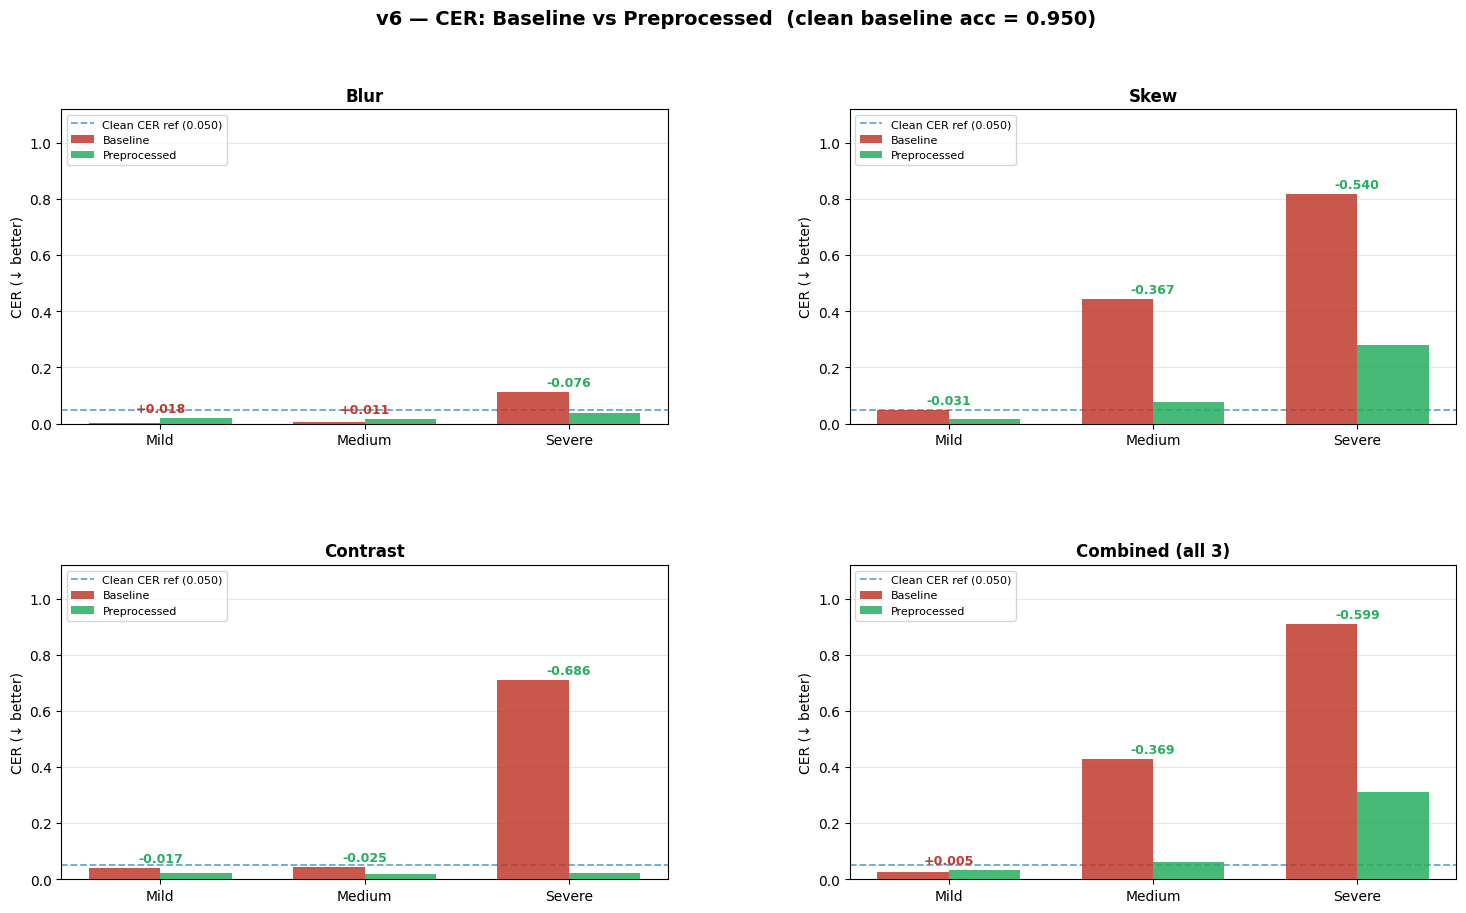

Saved: /content/v6_cer_bars.png


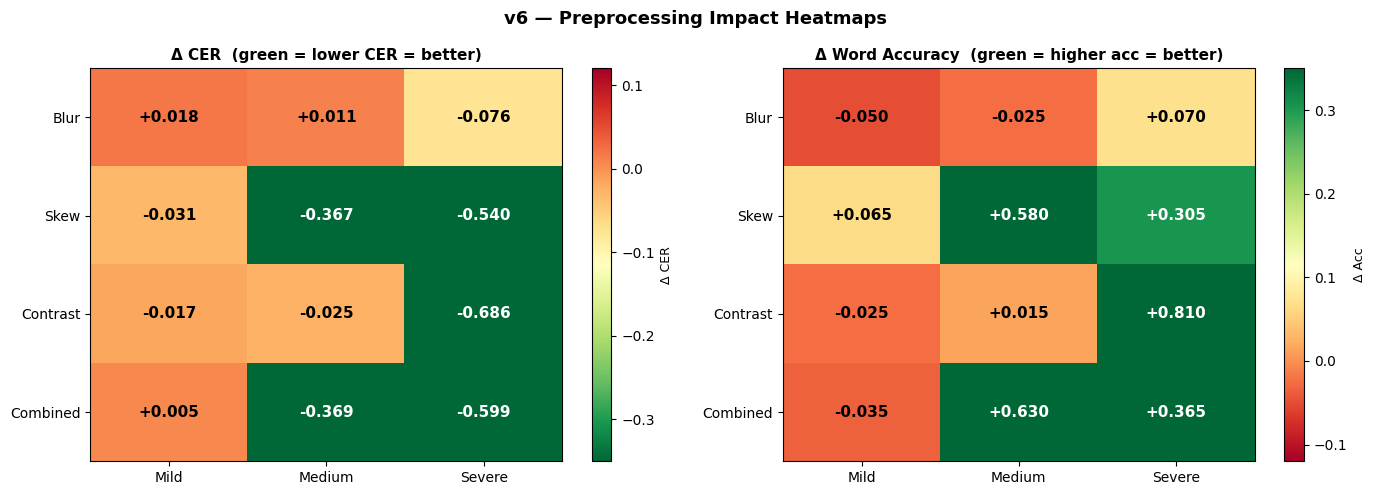

Saved: /content/v6_heatmaps.png


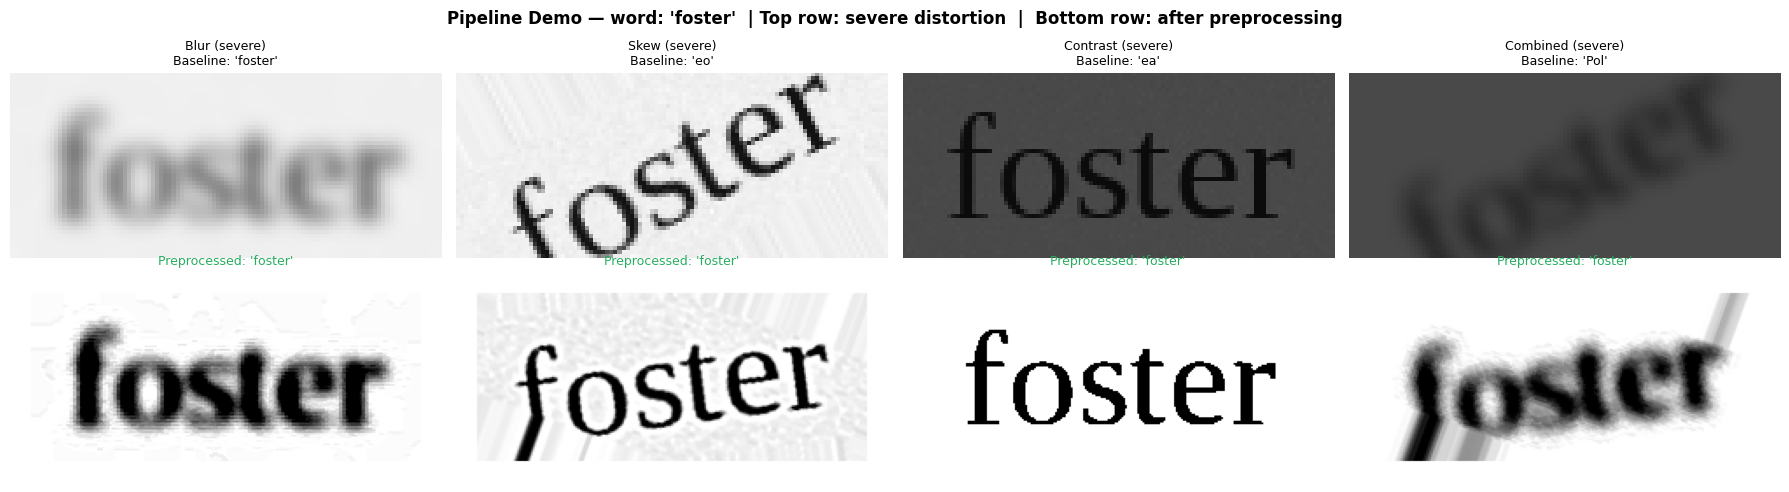

Saved: /content/v6_pipeline_demo.png

All done.


In [15]:
COLOR_BASE  = "#C0392B"
COLOR_PRE   = "#27AE60"
COLOR_CLEAN = "#2980B9"
SEV_LABELS  = [s.capitalize() for s in SEVERITIES]
BAR_W       = 0.35

# ── Fig 1: Grouped bar charts ────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.30)
fig.suptitle(
    f"v6 — CER: Baseline vs Preprocessed  "
    f"(clean baseline acc = {clean_acc:.3f})",
    fontsize=14, fontweight="bold"
)

# blur, skew, contrast, combined — 2×2 grid
plot_slots = [
    (0, 0, "blur"),
    (0, 1, "skew"),
    (1, 0, "contrast"),
    (1, 1, "combined"),
]

for row, col, dt in plot_slots:
    ax = fig.add_subplot(gs[row, col])
    x  = np.arange(len(SEVERITIES))

    if dt == "combined":
        base_cers = [np.mean(combined[s]["base_cer"]) for s in SEVERITIES]
        pre_cers  = [np.mean(combined[s]["pre_cer"])  for s in SEVERITIES]
    else:
        base_cers = [np.mean(results[dt][s]["base_cer"]) for s in SEVERITIES]
        pre_cers  = [np.mean(results[dt][s]["pre_cer"])  for s in SEVERITIES]

    ax.bar(x - BAR_W/2, base_cers, BAR_W,
           label="Baseline",     color=COLOR_BASE, alpha=0.85, zorder=3)
    ax.bar(x + BAR_W/2, pre_cers,  BAR_W,
           label="Preprocessed", color=COLOR_PRE,  alpha=0.85, zorder=3)

    # Clean reference line
    ax.axhline(1.0 - clean_acc, color=COLOR_CLEAN,
               linestyle="--", linewidth=1.3, alpha=0.7,
               label=f"Clean CER ref ({1-clean_acc:.3f})")

    for xi, (bv, pv) in enumerate(zip(base_cers, pre_cers)):
        delta  = pv - bv
        colour = COLOR_PRE if delta < 0 else COLOR_BASE
        ax.text(xi, max(bv, pv) + 0.02, f"{delta:+.3f}",
                ha="center", fontsize=9, color=colour, fontweight="bold")

    title = dt.capitalize() if dt != "combined" else "Combined (all 3)"
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xticks(x);  ax.set_xticklabels(SEV_LABELS, fontsize=10)
    ax.set_ylabel("CER (↓ better)", fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.legend(fontsize=8, loc="upper left")
    ax.grid(axis="y", alpha=0.3, zorder=0)

plt.savefig("/content/v6_cer_bars.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/v6_cer_bars.png")

# ── Fig 2: Dual heatmap ──────────────────────────────────────
rows_labels = DISTORTION_TYPES + ["combined"]
delta_cer   = np.zeros((len(rows_labels), len(SEVERITIES)))
delta_acc   = np.zeros((len(rows_labels), len(SEVERITIES)))

for ri, dt in enumerate(DISTORTION_TYPES):
    for ci, sv in enumerate(SEVERITIES):
        r = results[dt][sv]
        delta_cer[ri, ci] = np.mean(r["pre_cer"]) - np.mean(r["base_cer"])
        delta_acc[ri, ci] = np.mean(r["pre_acc"]) - np.mean(r["base_acc"])
for ci, sv in enumerate(SEVERITIES):
    c = combined[sv]
    delta_cer[-1, ci] = np.mean(c["pre_cer"]) - np.mean(c["base_cer"])
    delta_acc[-1, ci] = np.mean(c["pre_acc"]) - np.mean(c["base_acc"])

fig2, (ax_cer, ax_acc) = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("v6 — Preprocessing Impact Heatmaps",
              fontsize=13, fontweight="bold")

for ax, mat, title, cmap, vmin, vmax, cb_label in [
    (ax_cer, delta_cer,
     "Δ CER  (green = lower CER = better)",
     "RdYlGn_r", -0.35, 0.12, "Δ CER"),
    (ax_acc, delta_acc,
     "Δ Word Accuracy  (green = higher acc = better)",
     "RdYlGn",  -0.12, 0.35, "Δ Acc"),
]:
    im = ax.imshow(mat, cmap=cmap, aspect="auto", vmin=vmin, vmax=vmax)
    plt.colorbar(im, ax=ax).set_label(cb_label, fontsize=9)
    ax.set_xticks(range(len(SEVERITIES)))
    ax.set_xticklabels(SEV_LABELS, fontsize=10)
    ax.set_yticks(range(len(rows_labels)))
    ax.set_yticklabels([r.capitalize() for r in rows_labels], fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for ri in range(len(rows_labels)):
        for ci in range(len(SEVERITIES)):
            val = mat[ri, ci]
            ax.text(ci, ri, f"{val:+.3f}", ha="center", va="center",
                    fontsize=11, fontweight="bold",
                    color="white" if abs(val) > 0.18 else "black")

plt.tight_layout()
plt.savefig("/content/v6_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/v6_heatmaps.png")

# ── Fig 3: Visual pipeline demo ──────────────────────────────
demo_word, demo_img = eval_set[0]
fig3, axes3 = plt.subplots(2, 4, figsize=(18, 5))
fig3.suptitle(
    f"Pipeline Demo — word: '{demo_word}'  "
    f"| Top row: severe distortion  |  Bottom row: after preprocessing",
    fontsize=12, fontweight="bold"
)

demo_conditions = ["blur", "skew", "contrast", "combined"]
for col, cond in enumerate(demo_conditions):
    dist_img = (apply_combined(demo_img.copy(), "severe")
                if cond == "combined"
                else apply_distortion(demo_img.copy(), cond, "severe"))

    pre_img   = adaptive_preprocess(dist_img)
    pred_base = run_ocr(baseline_preprocess(dist_img))
    pred_pre  = run_ocr(pre_img)

    is_correct = pred_pre.lower() == demo_word.lower()

    axes3[0][col].imshow(dist_img, cmap="gray", vmin=0, vmax=255)
    axes3[0][col].set_title(
        f"{cond.capitalize()} (severe)\nBaseline: '{pred_base}'",
        fontsize=9)
    axes3[0][col].axis("off")

    axes3[1][col].imshow(pre_img, cmap="gray", vmin=0, vmax=255)
    axes3[1][col].set_title(
        f"Preprocessed: '{pred_pre}'",
        fontsize=9,
        color=COLOR_PRE if is_correct else COLOR_BASE)
    axes3[1][col].axis("off")

plt.tight_layout()
plt.savefig("/content/v6_pipeline_demo.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: /content/v6_pipeline_demo.png")
print("\nAll done.")



